<a href="https://colab.research.google.com/github/rambadade32/Citrurs_Disease_Detection/blob/added/Citrus_leaves_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!nvidia-smi

Wed Feb  3 11:46:06 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.39       Driver Version: 418.67       CUDA Version: 10.1     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   40C    P0    27W / 250W |      0MiB / 16280MiB |      0%      Default |
|                               |                      |                 ERR! |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [9]:
#!unzip "/content/drive/MyDrive/documents/archive (1).zip" -d"/content/drive/MyDrive/dataset"

# Leaf Disease Detection using CNN



In this project we're going to be using machine learning to help us identify different categories of Disease the plant have.

To do this, currently we'll be using data from the [Kaggle ](https://www.kaggle.com/dtrilsbeek/citrus-leaves-prepared) (and once our database  gets generated we'll integrate it with our this notebook.)The kaggle dataset is consists of a collection of 400+ images of
4 different citrus diseases.

This kind of problem is called multi-class image classification. It's multi-class because we're trying to classify four citrus Diseases. If we were only trying to classify dogs versus cats, it would be called binary classification (one thing versus another).

Multi-class image classification is an important problem because it's the same kind of technology Tesla uses in their self-driving cars or Airbnb uses in atuomatically adding information to their listings.

Since the most important step in a deep learng problem is getting the data ready (turning it into numbers), that's what we're going to start with.

We're going to go through the following TensorFlow/Deep Learning workflow:
1. Get data ready (download from Kaggle, store, import).
2. Prepare the data (preprocessing, the 3 sets, X & y).
3. Choose and fit/train a model ([TensorFlow Hub](https://www.tensorflow.org/hub), `tf.keras.applications`, [TensorBoard](https://www.tensorflow.org/tensorboard), [EarlyStopping](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)).
4. Evaluating a model (making predictions, comparing them with the ground truth labels).
5. Improve the model through experimentation (start with 1000 images, make sure it works, increase the number of images).
6. Save, sharing and reloading your model (once you're happy with the results).

For preprocessing our data, we're going to use TensorFlow 2.x. The whole premise here is to get our data into Tensors (arrays of numbers which can be run on GPUs) and then allow a machine learning model to find patterns between them.

For our machine learning model, we're going to be using a pretrained deep learning model from TensorFlow Hub. 

The process of using a pretrained model and adapting it to your own problem is called **transfer learning**. We do this because rather than train our own model from scratch (could be timely and expensive), we leverage the patterns of another model which has been trained to classify images.

## Getting our workspace ready

## Getting Data Ready


## Importing the required libraries 

In [10]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_hub as hub
print(hub.__version__)
from keras.preprocessing.image import ImageDataGenerator

0.11.0


### Accessing data
we're accessing the data as we've already unzipped the zip file,we've :
1. train and test dataset but we don't have validation dataset.
2. Data insufficiency
3. we'll look at the image features(like size,channels)
lets make the directories to train and test data paths


In [11]:
train_dir = "drive/MyDrive/dataset/train"
test_dir = "drive/MyDrive/dataset/test"

## Data preprocessing and Data Augumentation

In [12]:
train_datagen=ImageDataGenerator(zoom_range=0.2,horizontal_flip=True,
                                 rescale = 1./255,
                                 shear_range=0.2,
                                 validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

## Data Splitting
usually we split our data into `Training set`,`Validation set`and`Test set`.


Here we already have trin and test sets so we'll split our training dataset into validation dataset

In [13]:
IMG_SIZE = 224
path = "drive/MyDrive/dataset/val_set"
train_data = train_datagen.flow_from_directory(train_dir,target_size=(IMG_SIZE,IMG_SIZE),
                                               shuffle = True,
                                               seed=0,save_format ='png',
                                               subset ='training')
val_data = train_datagen.flow_from_directory(train_dir,target_size=(IMG_SIZE,IMG_SIZE),
                                             shuffle = False,
                                             subset = 'validation')


Found 381 images belonging to 4 classes.
Found 94 images belonging to 4 classes.


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Preprocessed test data of perticular format and shape
test_data = test_datagen.flow_from_directory(test_dir,target_size=(IMG_SIZE,IMG_SIZE),
                                             shuffle = False,
                                             )

Found 121 images belonging to 4 classes.


In [16]:
type(train_data.class_indices)

dict

In [17]:
#Types of diseases 
Diseases = []

x = train_data.class_indices
for name, i in x.items():
    Diseases.append(name)

Diseases

['blackspot', 'canker', 'greening', 'healthy']

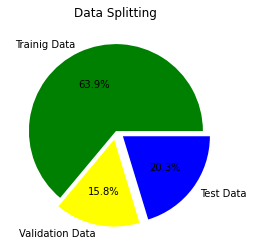

In [18]:
val =[len(train_data.filenames),
len(val_data.filenames),
len(test_data.filenames)]

label=['Trainig Data','Validation Data','Test Data']
colours = ["green",'yellow','blue']
plt.pie(x=val,labels=label,colors=colours,explode=(0,0.1,0.1),autopct="%1.1f%%")
plt.title("Data Splitting");

### see some images


In [19]:

from IPython.display import Image,display

def show_image(filepath):
   
   for i in range(2):
  
        im = Image("/content/drive/MyDrive/dataset/train/"+filepath[i])
     
        print(filepath[i])

        display(im)

blackspot/b (165).png


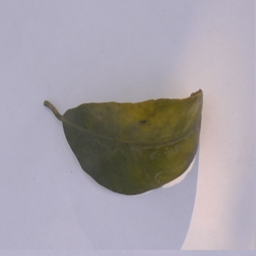

blackspot/b (166).png


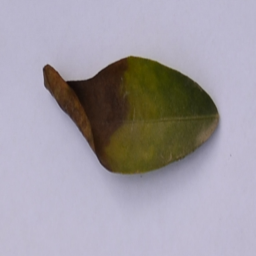

In [20]:
show_image(train_data.filenames)

greening/g (10).png


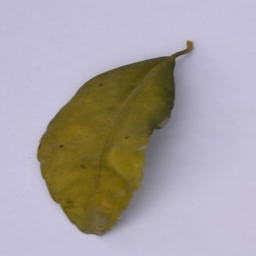

greening/g (100).png


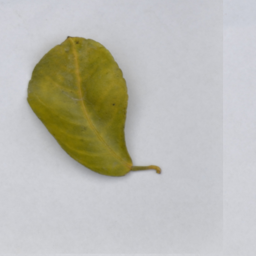

In [21]:
show_image(val_data.filenames[54:56])

## Creating our model

In [22]:
# Setup input shape to the model
INPUT_SHAPE = [None, IMG_SIZE, IMG_SIZE, 3] # batch, height, width, colour channels

# Setup output shape of the model
OUTPUT_SHAPE = len(Diseases) # number of unique labels

# Setup model URL from TensorFlow Hub
MODEL_URL = "https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4"

In [23]:
OUTPUT_SHAPE

4

In [24]:
# Create a function which builds a Keras model
def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
  print("Building model with:", MODEL_URL)

  # Setup the model layers
  model = tf.keras.Sequential([
    hub.KerasLayer(MODEL_URL), # Layer 1 (input layer)
    tf.keras.layers.Dense(units=OUTPUT_SHAPE, 
                          activation="softmax") # Layer 2 (output layer)
  ])

  # Compile the model
  model.compile(
      loss=tf.keras.losses.CategoricalCrossentropy(), # Our model wants to reduce this (how wrong its guesses are)
      optimizer=tf.keras.optimizers.Adam(), # A friend telling our model how to improve its guesses
      metrics=["accuracy"] # We'd like this to go up
  )

  # Build the model
  model.build(INPUT_SHAPE) # Let the model know what kind of inputs it'll be getting
  
  return model

In [25]:
# Create a model and check its details
model = create_model()
model.summary()

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
keras_layer (KerasLayer)     (None, 1001)              5432713   
_________________________________________________________________
dense (Dense)                (None, 4)                 4008      
Total params: 5,436,721
Trainable params: 4,008
Non-trainable params: 5,432,713
_________________________________________________________________


In [26]:
%load_ext tensorboard

## tensorboard callback

In [113]:
import datetime
import os

# Create a function to build a TensorBoard callback
def create_tensorboard_callback():
  """
  dir_model_log after dataset folder in drive
  """
  # Create a log directory for storing TensorBoard logs
  logdir = os.path.join("/content/drive/MyDrive/dataset/nasa/nasa_logs",
                        # Make it so the logs get tracked whenever we run an experiment
                        datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
  return tf.keras.callbacks.TensorBoard(logdir)

In [28]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",patience=2),
    tf.keras.callbacks.ModelCheckpoint(filepath='/content/drive/MyDrive/dataset/callback'),
    create_tensorboard_callback()
]

In [29]:
# Build a function to train and return a trained model
def train_model():
  """
  Trains a given model and returns the trained version.
  """
  # Create a model
  model = create_model()

  # Create new TensorBoard session everytime we train a model
  #tensorboard = create_tensorboard_callback()

  # Fit the model to the data passing it the callbacks we created
  model.fit(x=train_data,
            epochs=100,
            validation_data=val_data,
            validation_freq=1, # check validation metrics every epoch
            callbacks=my_callbacks)
  
  return model

In [30]:
#model = train_model()

In [31]:
#function to save a model

def save_model(model,suffix=None):
  model_dir = os.path.join("drive/MyDrive/dataset/models",
                            datetime.datetime.now().strftime("%Y%m%D-%H%M%S"))
  model_path = model_dir + suffix +".h5"
  model.save(model_path)
  print (f"saving model at {model_path}...")
  return model_path

In [32]:
#function to load a model

def load_model(model_path):
  """
  Loads a saved model from a specified path.
  """
  print(f"Loading saved model from: {model_path}")
  model = tf.keras.models.load_model(model_path,
                                     custom_objects={"KerasLayer":hub.KerasLayer})
  return model

In [33]:
#model.save("/content/drive/MyDrive/dataset/models/cit.h5")
#save_model(model=model,citrus)

In [34]:
model = load_model("/content/drive/MyDrive/dataset/models/cit.h5")

Loading saved model from: /content/drive/MyDrive/dataset/models/cit.h5


In [35]:
#model.evaluate(val_data,verbose = 1)

## Validation Prediction

In [36]:
# Turn prediction probabilities into their respective label (easier to understand)
def get_pred_label(prediction_probabilities):
  """
  Turns an array of prediction probabilities into a label.
  """
  return Diseases[np.argmax(prediction_probabilities)]

# Get a predicted label based on an array of prediction probabilities

In [37]:
def get_label(prediction_probabilities):
   '''
   takes numpy array and returns label of highest probability
   '''
   return  Diseases[np.argmax(prediction_probabilities)]

In [38]:
labels=[]

for i in range(len(test_data.labels)):
    labels.append(test_data.labels[i])

true_labels=[]
for i in range(len(test_data.labels)):
  true_labels.append(Diseases[labels[i]])

In [39]:

val_image = []
for i in range(len(val_data.filenames)):
  val_image.append("drive/MyDrive/dataset/train/"+val_data.filenames[i])

In [40]:
val_image[0:10]

['drive/MyDrive/dataset/train/blackspot/74.jpg',
 'drive/MyDrive/dataset/train/blackspot/78.jpg',
 'drive/MyDrive/dataset/train/blackspot/b (11).png',
 'drive/MyDrive/dataset/train/blackspot/b (126).png',
 'drive/MyDrive/dataset/train/blackspot/b (131).png',
 'drive/MyDrive/dataset/train/blackspot/b (134).png',
 'drive/MyDrive/dataset/train/blackspot/b (139).png',
 'drive/MyDrive/dataset/train/blackspot/b (14).png',
 'drive/MyDrive/dataset/train/blackspot/b (140).png',
 'drive/MyDrive/dataset/train/blackspot/b (142).png']

In [41]:
#vpred=model.predict(val_data,verbose=1)

In [42]:
#val_preds = np.save("drive/MyDrive/Val_preds_1",vpred)

In [43]:
val_preds = np.load("drive/MyDrive/Val_preds_1.npy")

In [44]:
len(val_preds)

94

In [45]:
val_preds.shape

(94, 4)

In [46]:
val_preds.dtype

dtype('float32')

In [47]:
# np.round(val_preds)

In [48]:
val_data.class_indices

{'blackspot': 0, 'canker': 1, 'greening': 2, 'healthy': 3}

In [49]:
# First prediction
print(val_preds[0])
print(f"Max value (probability of prediction): {np.max(val_preds[0])}") # the max probability value predicted by the model
print(f"Sum: {np.sum(val_preds[0])}") # because we used softmax activation in our model, this will be close to 1
print(f"Max index: {np.argmax(val_preds[0])}") # the index of where the max value in predictions[0] occurs
print(f"Predicted label: {Diseases[np.argmax(val_preds[0])]}") # the predicted label

[0.4311049  0.37357295 0.19406855 0.00125356]
Max value (probability of prediction): 0.4311048984527588
Sum: 0.9999999403953552
Max index: 0
Predicted label: blackspot


In [50]:
x=plt.imread(val_image[0])

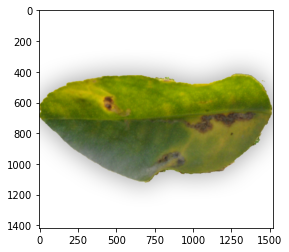

In [51]:
plt.imshow(x);

## Creating vizualization functions

In [52]:
# plotting prediction with predicted label and confirmed with true label
# of given image with image for vizualization
def plot_predictions(prediction_probabilities,labels,images,n=1):
    
    pred_probs,actual_label, real_image = prediction_probabilities[n],labels[n],images[n]

    pred_labels= get_label(pred_probs)
    
    # plot image
    x = plt.imread(real_image)
    plt.imshow(x)

    if pred_labels == actual_label:
       color = "green"
    else:
       color = "red"   

    # give title as predictions and actual 
    plt.title("Prediction-{:.2f}-{} || Actual-{}".format(np.max(pred_probs)*100,
                                             pred_labels,
                                             actual_label),
                                             color = color)

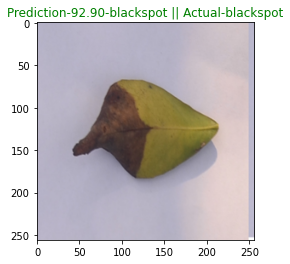

In [53]:
plot_predictions(val_preds,true_labels,val_image,n=24)

In [54]:
#plotting Probabilities of classification of each disease 
def plot_pred_conf(prediction_probabilities, labels, n=1):
  """
  Plots the top 4 highest prediction confidences along with
  the truth label for sample n.
  """
  pred_prob, true_label = prediction_probabilities[n], labels[n]

  # Get the predicted label
  pred_label = get_pred_label(pred_prob)

  # Find the top 10 prediction confidence indexes
  top_4_pred_indexes = pred_prob.argsort()[-4:][::-1]
  # Find the top 10 prediction confidence values
  top_4_pred_values = pred_prob[top_4_pred_indexes]
  # Find the top 10 prediction labels
  top_4_pred_labels = Diseases

  # Setup plot
  top_plot = plt.bar(np.arange(len(top_4_pred_labels)), 
                     top_4_pred_values, 
                     color="grey")
  plt.xticks(np.arange(len(top_4_pred_labels)),
             labels=top_4_pred_labels,
             rotation="vertical")

  # Change color of true label
  if np.isin(true_label, top_4_pred_labels):
    top_plot[np.argmax(top_4_pred_labels == true_label)].set_color("green")
  else:
    pass

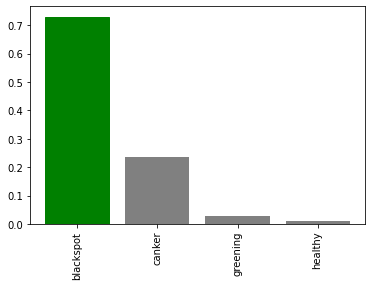

In [55]:
plot_pred_conf(prediction_probabilities=val_preds,
               labels=true_labels,
               n=9)

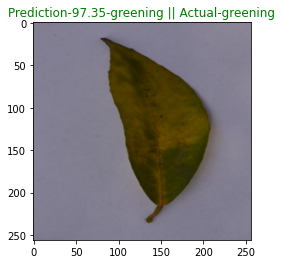

In [56]:

plot_predictions(val_preds,true_labels,val_image,72)

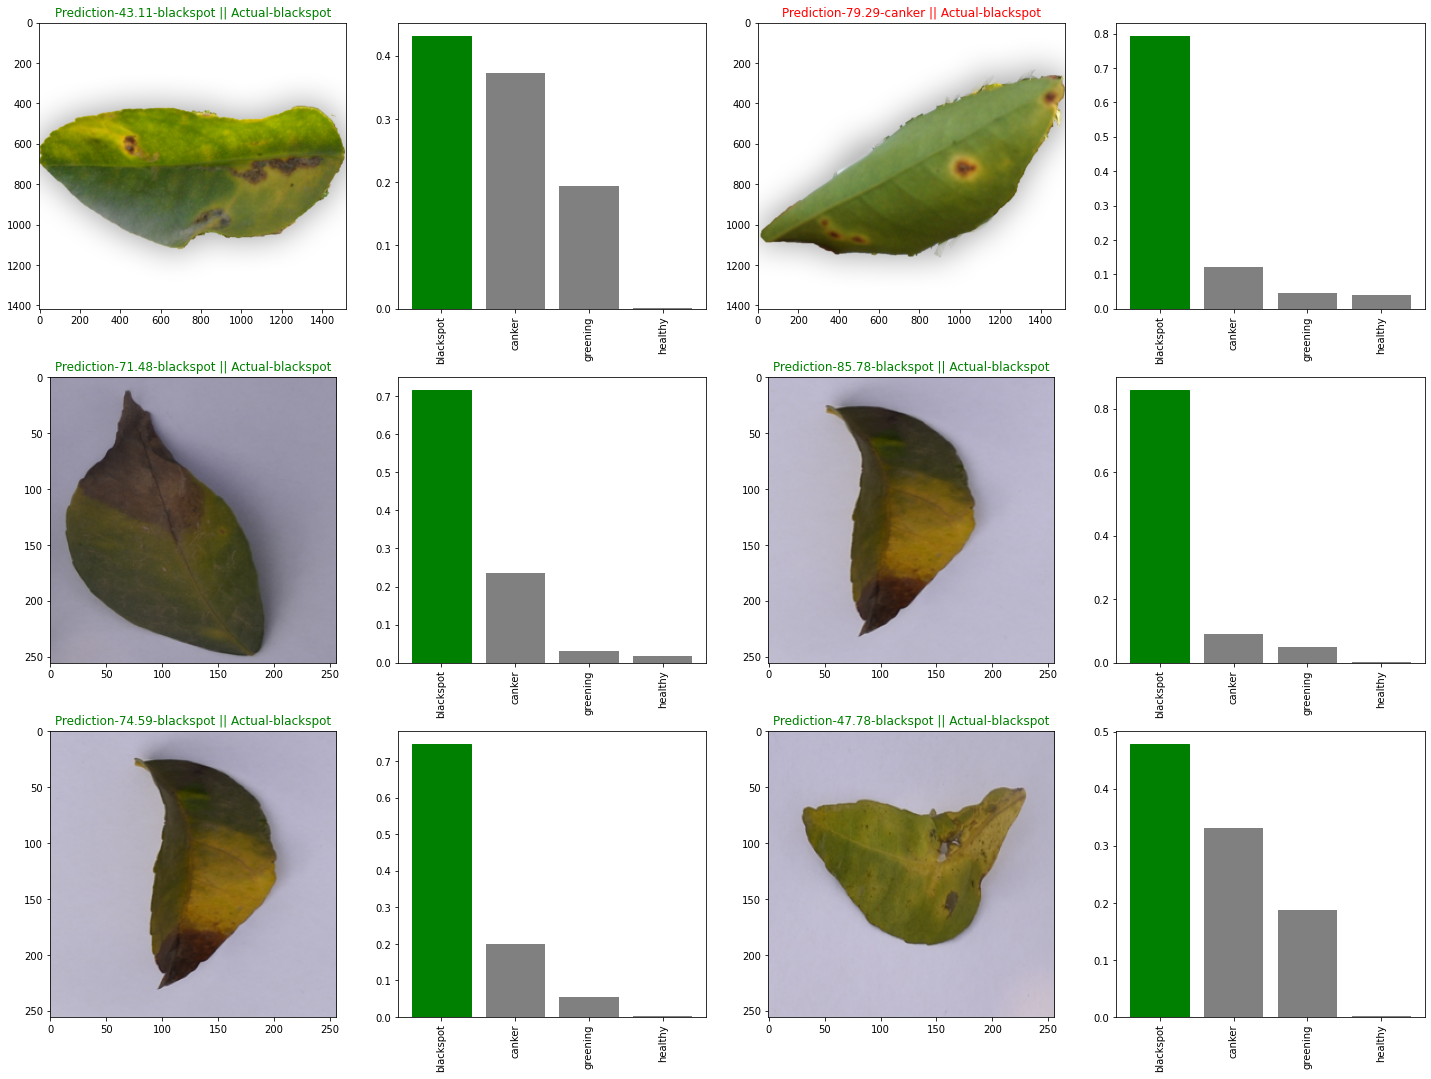

In [57]:
# Let's check a few predictions and their different values
i_multiplier = 0
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(5*2*num_cols, 5*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_predictions(prediction_probabilities=val_preds,
            labels=true_labels,
            images=val_image,
            n=i+i_multiplier)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_pred_conf(prediction_probabilities=val_preds,labels=true_labels,n=i+i_multiplier)
plt.tight_layout(h_pad=1.0)
plt.show()

## Test Predictions

In [58]:
# Getting true test labels
labels=[]

for i in range(len(test_data.labels)):
    labels.append(test_data.labels[i])

true_test_labels=[]
for i in range(len(test_data.labels)):
  true_test_labels.append(Diseases[labels[i]])

In [59]:
true_test_labels[:20]

['blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot',
 'blackspot']

In [60]:
len(Diseases)

4

In [61]:
#Getting image paths of test data
img = ["/content/drive/MyDrive/dataset/test/"+fname for fname in test_data.filenames]
img[:3]

['/content/drive/MyDrive/dataset/test/blackspot/b (250).png',
 '/content/drive/MyDrive/dataset/test/blackspot/b (251).png',
 '/content/drive/MyDrive/dataset/test/blackspot/b (252).png']

In [62]:
#test_predictions = model.predict(test_data,verbose=1)

In [63]:
#test_predictions = np.save("/content/drive/MyDrive/citrus_test_preds",test_predictions)

In [64]:
test_preds = np.load("/content/drive/MyDrive/citrus_test_preds.npy",allow_pickle=True)

In [65]:
test_preds

array([[4.36725207e-02, 4.10842942e-03, 9.51656878e-01, 5.62105153e-04],
       [3.42444897e-01, 2.20230361e-03, 6.48013830e-01, 7.33897183e-03],
       [2.45500758e-01, 4.39343601e-03, 7.49140203e-01, 9.65615734e-04],
       [7.18660355e-01, 7.22540841e-02, 2.01194003e-01, 7.89159536e-03],
       [1.55336574e-01, 6.56614751e-02, 4.79512870e-01, 2.99489141e-01],
       [5.42863965e-01, 6.13360666e-02, 3.60434741e-01, 3.53652276e-02],
       [7.36243844e-01, 5.37681431e-02, 1.90853879e-01, 1.91341285e-02],
       [1.09535262e-01, 2.85890788e-01, 3.44038069e-01, 2.60535896e-01],
       [2.66659915e-01, 6.64466806e-03, 6.34941518e-01, 9.17538926e-02],
       [2.68453091e-01, 6.64887130e-01, 5.89579120e-02, 7.70185748e-03],
       [4.48711038e-01, 8.50149244e-02, 4.44327176e-01, 2.19468437e-02],
       [8.97861600e-01, 5.30631281e-02, 2.43549310e-02, 2.47203745e-02],
       [5.14596879e-01, 1.05713843e-03, 4.83997494e-01, 3.48494883e-04],
       [7.28999138e-01, 2.95274947e-02, 2.15244219e

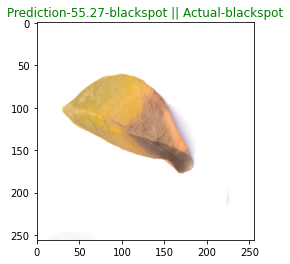

In [66]:
plot_predictions(test_preds,true_test_labels,img,25)

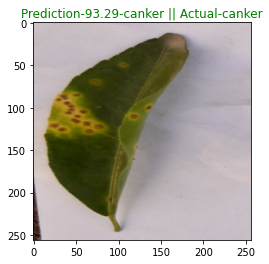

In [67]:
plot_predictions(test_preds,true_test_labels,img,36)

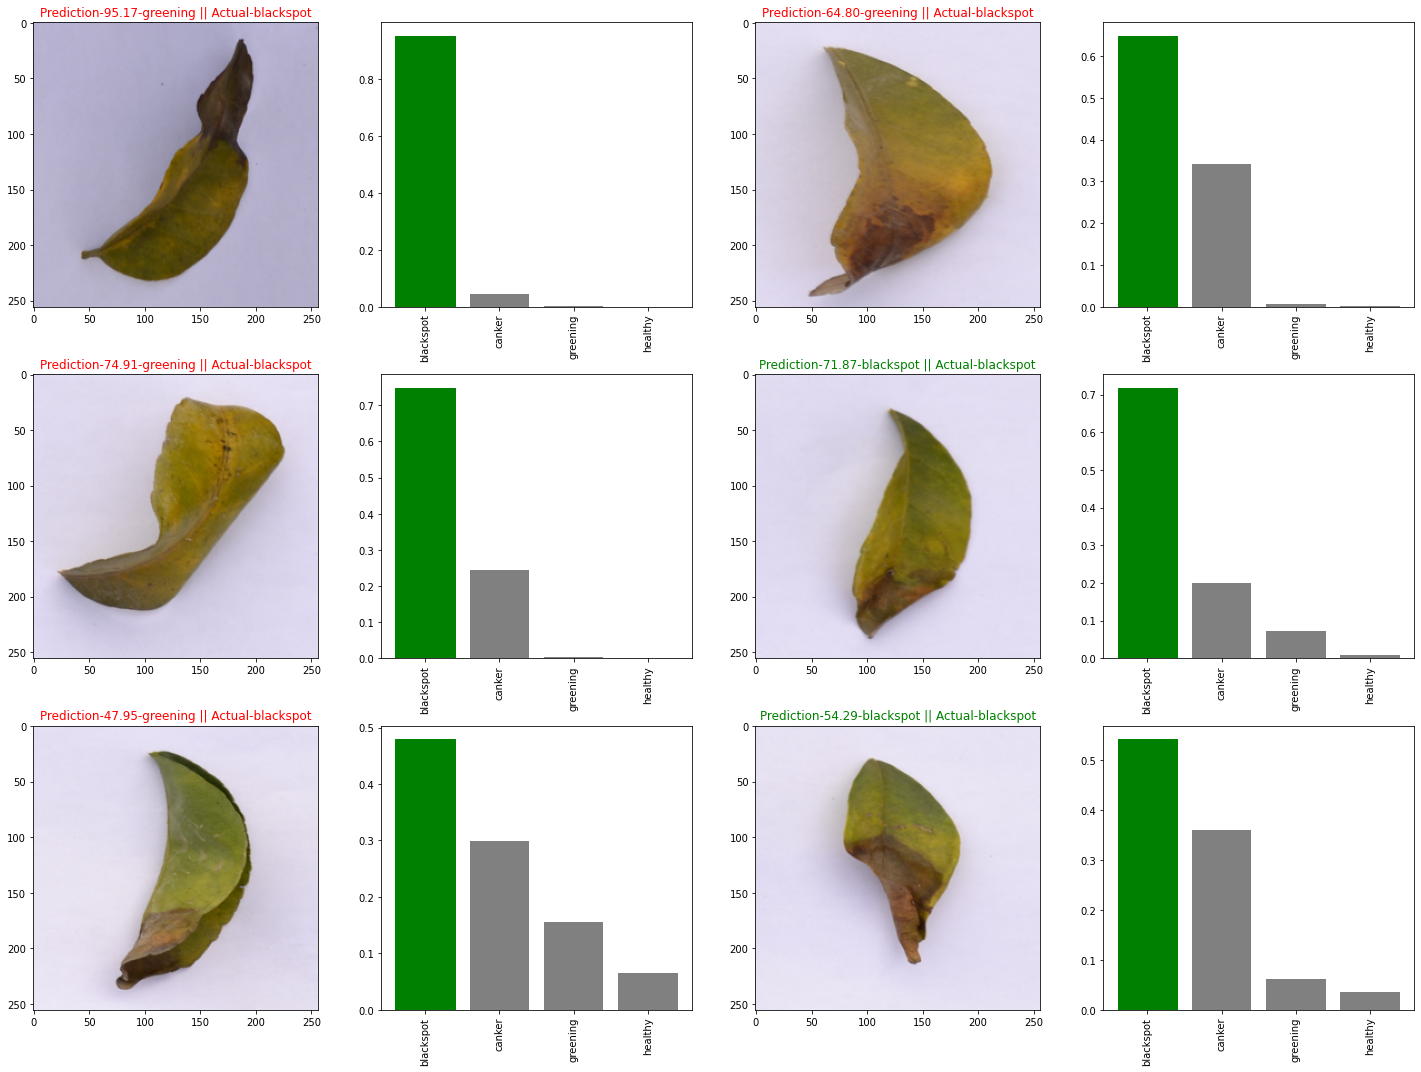

In [68]:
# Let's check a few predictions and their different values
i_multiplier = 0
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(5*2*num_cols, 5*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_predictions(prediction_probabilities=test_preds,
            labels=true_test_labels,
            images=img,
            n=i+i_multiplier)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_pred_conf(prediction_probabilities=test_preds,labels=true_test_labels,n=i+i_multiplier)
plt.tight_layout(h_pad=1.0)
plt.show()

# Training another models to get a better accuracy 

Upto here we've trained a model using a `Transfer Learnig` on only 80% images in our `Trainig data`and got an amazing accuracy on validation set about `75%` we've now tensorboard logs to track an accuracy while training a model on All of our data...

Now we're going to train different Pretrained models on our `80% of training data` and further we'll Train a Model which got an better accuracy and timing also on `full data` 




### Here we'll use  pre-trained models on Tensorflow hub

To use pre-trained models we'll required its url which easily gets on tensorflow hub

In [69]:
EFFICIENT_NET = "https://tfhub.dev/tensorflow/efficientnet/b0/classification/1"

In [70]:
NASA_NET="https://tfhub.dev/google/imagenet/nasnet_mobile/classification/4"#224

In [71]:
INCEPTION_RESNET = "https://tfhub.dev/google/imagenet/inception_resnet_v2/classification/4"#299

In [72]:
print(f"length of train data ={len(train_data.filenames)}  length of validation data ={len(val_data.filenames)}")


length of train data =381  length of validation data =94


In [73]:
eff_net = create_model(model_url=EFFICIENT_NET)

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4


In [74]:
eff_net.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
keras_layer_1 (KerasLayer)   (None, 1001)              5432713   
_________________________________________________________________
dense_1 (Dense)              (None, 4)                 4008      
Total params: 5,436,721
Trainable params: 4,008
Non-trainable params: 5,432,713
_________________________________________________________________


In [75]:
#eff_net = train_model()

In [76]:
#eff_net = save_model(eff_net,"eff_net_subset")

In [77]:
model_eff = load_model("drive/MyDrive/dataset/models/20210202/03/21-113521eff_net_subset.h5")

Loading saved model from: drive/MyDrive/dataset/models/20210202/03/21-113521eff_net_subset.h5


In [79]:
model_eff.evaluate(val_data)

3/3 [==============================] - 29s 11s/step - loss: 0.4746 - accuracy: 0.8191


[0.474578320980072, 0.8191489577293396]

In [80]:
#eff_val_pred = model_eff.predict(val_data,verbose=1)
#eff_val_pred = np.save("/content/drive/MyDrive/dataset/eff_net/eff_val_pred",eff_val_pred)

3/3 [==============================] - 2s 495ms/step


In [81]:
eff_val_pred = np.load("/content/drive/MyDrive/dataset/eff_net/eff_val_pred.npy")

In [85]:
eff_val_pred[:10]

array([[3.0447569e-01, 3.3587492e-01, 3.5585293e-01, 3.7964848e-03],
       [1.1924573e-02, 9.8445451e-01, 1.4066165e-03, 2.2143056e-03],
       [9.6959597e-01, 1.7566090e-02, 9.6990857e-03, 3.1388297e-03],
       [5.9876037e-01, 1.6419603e-03, 3.9946842e-01, 1.2915561e-04],
       [7.3838234e-01, 2.1226658e-02, 2.3993663e-01, 4.5438876e-04],
       [8.5659724e-01, 7.9702668e-02, 6.3172005e-02, 5.2806473e-04],
       [3.2792532e-01, 3.0663509e-02, 6.3796717e-01, 3.4440302e-03],
       [3.8696858e-01, 1.2440715e-01, 4.8373672e-01, 4.8874919e-03],
       [9.4617152e-01, 3.9505688e-03, 1.8539643e-02, 3.1338282e-02],
       [3.0099392e-01, 1.0879056e-02, 6.8426067e-01, 3.8663363e-03]],
      dtype=float32)

In [84]:
np.round(eff_val_pred)[:10]

array([[0., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.]], dtype=float32)

In [100]:
Diseases

['blackspot', 'canker', 'greening', 'healthy']

In [101]:
labels[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [88]:
x = eff_val_pred[0]

In [104]:
print(f" max probability: {np.max(x)*100}")
print(f"it's index:{np.argmax(x)} ")
print(f"hence it belongs to Disease-{Diseases[np.argmax(x)]}")
# as we've used softmax acivation 
print(f"Sum of all probabiliries = {np.sum(x)}")

 max probability: 35.58529317378998
it's index:2 
hence it belongs to Disease-greening
Sum of all probabiliries = 1.0


#Vizualize validation prediction of eff net 
To vizualise some images and labels predicted by efficientnet on val data we've our true validation labels and image paths in validation data




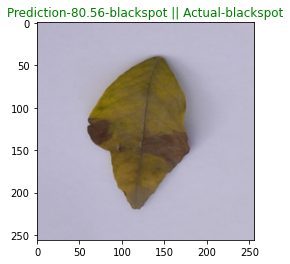

In [103]:
plot_predictions(eff_val_pred,true_labels,val_image,10)

In [111]:
for i in range(93):
  print(f"pred :{np.round(eff_val_pred[i])} --{true_labels[i]}")

pred :[0. 0. 0. 0.] --blackspot
pred :[0. 1. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[0. 0. 1. 0.] --blackspot
pred :[0. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[0. 0. 1. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[0. 1. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[0. 0. 0. 0.] --blackspot
pred :[0. 0. 1. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[0. 0. 1. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[0. 0. 1. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[0. 1. 0. 0.] --blackspot
pred :[0. 1. 0. 0.] --blackspot
pred :[0. 1. 0. 0.] --blackspot
pred :[1. 0. 0. 0.] --blackspot
pred :[0

In [112]:
nasa_net = create_model(model_url = NASA_NET)
nasa_net.summary()

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4
Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
keras_layer_3 (KerasLayer)   (None, 1001)              5432713   
_________________________________________________________________
dense_3 (Dense)              (None, 4)                 4008      
Total params: 5,436,721
Trainable params: 4,008
Non-trainable params: 5,432,713
_________________________________________________________________


In [114]:
#nasa_net = train_model()

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4
Epoch 1/100
12/12 [==============================] - 169s 14s/step - loss: 1.5203 - accuracy: 0.3727 - val_loss: 0.9459 - val_accuracy: 0.7128
INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


Epoch 2/100
12/12 [==============================] - 8s 640ms/step - loss: 0.7510 - accuracy: 0.7113 - val_loss: 0.6756 - val_accuracy: 0.7340
INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


Epoch 3/100
12/12 [==============================] - 8s 641ms/step - loss: 0.5135 - accuracy: 0.8351 - val_loss: 0.6155 - val_accuracy: 0.7660
INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


...

INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


Epoch 5/100
12/12 [==============================] - 8s 693ms/step - loss: 0.2902 - accuracy: 0.9265 - val_loss: 0.5515 - val_accuracy: 0.7766
INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


Epoch 6/100
12/12 [==============================] - 7s 632ms/step - loss: 0.2691 - accuracy: 0.9068 - val_loss: 0.5409 - val_accuracy: 0.7979
INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/dataset/callback/assets


In [115]:
#save_model(nasa_net , "nasa_net_subset")

saving model at drive/MyDrive/dataset/models/20210202/03/21-123809nasa_net_subset.h5...


'drive/MyDrive/dataset/models/20210202/03/21-123809nasa_net_subset.h5'

In [116]:
model_nasa = load_model("drive/MyDrive/dataset/models/20210202/03/21-123809nasa_net_subset.h5")

Loading saved model from: drive/MyDrive/dataset/models/20210202/03/21-123809nasa_net_subset.h5


In [117]:
model_nasa.evaluate(val_data)

3/3 [==============================] - 2s 471ms/step - loss: 0.5362 - accuracy: 0.7766


[0.5361636281013489, 0.7765957713127136]

In [118]:
#nasa_val_pred = model_nasa.predict(val_data,verbose= 1)

3/3 [==============================] - 2s 483ms/step


In [119]:
#nasa_val_pred = np.save("/content/drive/MyDrive/dataset/nasa/nasa_val_pred",nasa_val_pred)

In [121]:
nasa_val_pred

In [122]:
nasa_val_pred = np.load("/content/drive/MyDrive/dataset/nasa/nasa_val_pred.npy")

In [125]:
np.round(nasa_val_pred)[:10]

In [127]:
for i in range(25,75):
  print(f"{np.round(nasa_val_pred[i])} -- {true_labels[i]}")


[0. 0. 1. 0.] -- blackspot
[1. 0. 0. 0.] -- blackspot
[0. 1. 0. 0.] -- blackspot
[0. 1. 0. 0.] -- blackspot
[0. 1. 0. 0.] -- blackspot
[1. 0. 0. 0.] -- blackspot
[0. 0. 0. 0.] -- blackspot
[0. 1. 0. 0.] -- blackspot
[0. 1. 0. 0.] -- blackspot
[0. 1. 0. 0.] -- blackspot
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[1. 0. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[0. 1. 0. 0.] -- canker
[1. 0. 0. 0.] -- canker
[0. 0. 0. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 0.] -- canker
[0. 0. 1. 